# Toy Experiment: Explanatory Note and Result Display


## 1. Objective

This toy experiment is a controlled preliminary simulation for Prediction-Powered Inference. It compares Classic inference, Naive ML, PPI, and PPI++V2 under three statistical settings: mean estimation, linear regression, and logistic GLM. The comparison is conducted from the perspective of learner quality, with empirical coverage and confidence-interval width used as the main inferential-performance metrics.

Cross-PPI is retained only as an interface and is not included in the current result display.


## 2. Formulation

### 2.1 PPI

For mean estimation, PPI uses

$$
\widehat\theta_{\mathrm{PPI}}
=
\frac{1}{n}\sum_{i=1}^{n}Y_i
+
\left(
\frac{1}{N}\sum_{j=1}^{N}f(X_j^u)
-
\frac{1}{n}\sum_{i=1}^{n}f(X_i)
\right).
$$

The first term uses labelled data, while the bracketed term uses unlabelled predictions and labelled correction. For linear regression and logistic GLM, the same idea is implemented at the estimating-equation level.


### 2.2 PPI++V2

The method reported here as PPI++V2 is the variance-minimizing weighted PPI implementation used in this toy experiment. It is not the paper-based covariance-to-variance-ratio rule.

For mean estimation, PPI++V2 considers a weighted PPI estimator indexed by $\lambda\in[0,1]$:

$$
\widehat\theta_{\lambda}
=
\frac{1}{n}\sum_{i=1}^{n}Y_i
+
\lambda
\left(
\frac{1}{N}\sum_{j=1}^{N}f(X_j^u)
-
\frac{1}{n}\sum_{i=1}^{n}f(X_i)
\right).
$$

The boundary cases are

$$
\lambda=0\Rightarrow\text{Classic},
\qquad
\lambda=1\Rightarrow\text{PPI}.
$$

For a fixed $\lambda$, the variance estimator in the mean-estimation case is

$$
\widehat{\operatorname{Var}}(\widehat\theta_{\lambda})
=
\frac{
\widehat{\operatorname{Var}}\{Y_i-\lambda f(X_i)\}_{i=1}^{n}
}{n}
+
\lambda^2
\frac{
\widehat{\operatorname{Var}}\{f(X_j^u)\}_{j=1}^{N}
}{N}.
$$

This variance has two parts. The first term is the labelled correction uncertainty. It is not only the variance of the true labels. It also contains the variance of the learner output and the covariance between the true label and the learner output, because

$$
\operatorname{Var}\{Y-\lambda f(X)\}
=
\operatorname{Var}(Y)
+
\lambda^2\operatorname{Var}\{f(X)\}
-
2\lambda\operatorname{Cov}\{Y,f(X)\}.
$$

The second term is the uncertainty from the unlabelled prediction-powered component. It depends on the variation of $f(X^u)$ on the unlabelled sample and is scaled by $\lambda^2$.

For linear regression and logistic GLM, the same idea is implemented at the estimating-equation level. For each fixed $\lambda$, toyv2 first solves the corresponding weighted estimating equation and then computes a sandwich covariance matrix,

$$
\widehat V_\lambda
=
\widehat H_\lambda^{-1}
\widehat\Omega_\lambda
\widehat H_\lambda^{-T}.
$$

Here, $\widehat H_\lambda$ is the empirical Hessian or Jacobian of the weighted estimating equation. The middle term $\widehat\Omega_\lambda$ collects the variation from two sources:

$$
\widehat\Omega_\lambda
=
\frac{1}{n}
\widehat{\operatorname{Cov}}
\left\{
\psi_i^L(\widehat\theta_\lambda;\lambda)
\right\}
+
\frac{1}{N}
\widehat{\operatorname{Cov}}
\left\{
\psi_j^U(\widehat\theta_\lambda;\lambda)
\right\}.
$$

The term $\psi_i^L$ is the labelled-sample contribution, which contains the correction based on the difference between the true label and the learner output. The term $\psi_j^U$ is the unlabelled-sample prediction-powered contribution. Thus, $\widehat V_\lambda$ is not simply built from learner variance and label variance separately. It is built from the variance of labelled correction contributions and the variance of unlabelled prediction-powered contributions, with the relationship between $Y$ and $f(X)$ entering through the labelled correction part.

PPI++V2 then searches over the grid $\Lambda=\texttt{PPI\_PLUS\_PLUS\_LAMBDA\_GRID}$ and selects

$$
\widehat{\lambda}
=
\arg\min_{\lambda\in\Lambda}
\operatorname{tr}
\left(
\widehat V_\lambda
\right).
$$

For mean estimation, $\operatorname{tr}(\widehat V_\lambda)$ is just the scalar estimated variance. For linear regression and logistic GLM, $\widehat V_\lambda$ is a covariance matrix for all coefficients, so the trace criterion minimizes the sum of estimated coefficient variances.

This is a vector-level variance criterion. It can reduce the overall covariance trace, but it does not guarantee a shorter confidence interval for every individual coefficient in every replicate.

## 3. Toy Design

### 3.1 Data Settings

We consider three settings:

1. Mean estimation;
2. Linear regression;
3. Logistic GLM.

The covariates are generated as

$$
X=(1,X_1,X_2)^\top,
\qquad
X_1\sim U(-1,1),
\qquad
X_2\sim \mathrm{Bernoulli}(0.5).
$$

The common signal is

$$
\eta(X)=0.25+0.9X_1-0.6X_2.
$$

For mean estimation and linear regression,

$$
Y=\eta(X)+\epsilon,
\qquad
\epsilon\sim N(0,1).
$$

For logistic GLM,

$$
Y\mid X\sim\mathrm{Bernoulli}\{\operatorname{expit}(\eta(X))\}.
$$

The default sample sizes are $n=60$ labelled observations and $N=600$ unlabelled observations.


### 3.2 Learner-Quality Control

Learner quality is controlled through pseudo learner outputs rather than separately trained ML algorithms. For each scenario, let $z(X)$ be the true conditional mean. The proxy output is

$$
f(X)=z(X)+e(X).
$$

| Profile | Error structure | Interpretation |
|---|---:|---|
| P1 | $e=0.02U,\ U\sim U(-1,1)$ | small random error |
| P2 | $e=0.06$ | constant global bias |
| P3 | $e=0.06(2X_2-1)$ | random directions error |
| P4 | $e=0.20U,\ U\sim U(-1,1)$ | larger random error |


### 3.3 Compared Methods

| Method | Role |
|---|---|
| Classic | labelled-data-only inference |
| Naive ML | diagnostic baseline using predictions as if they were labels |
| PPI | prediction-powered inference with labelled correction |
| PPI++V2 | variance-minimizing weighted PPI variant |

Naive ML is included only as a diagnostic baseline, because narrow intervals are not meaningful when coverage is invalid.


## 4. Outputs with Description

### 4.1 Main Metrics

The outputs are evaluated mainly by empirical coverage and confidence-interval width.

| Metric | Definition | What it evaluates | Interpretation |
|---|---|---|---|
| Empirical Coverage | $\widehat{\mathrm{Coverage}}=\frac{1}{B}\sum_{b=1}^{B}\mathbf{1}\{\theta^\star\in CI^{(b)}\}$ | Validity | Should be close to the nominal confidence level |
| Coverage Error | $\widehat{\mathrm{Coverage}}-\text{Nominal Level}$ | Calibration | Values closer to 0 indicate better calibration |
| Average CI Width | $\widehat{\mathrm{Width}}=\frac{1}{B}\sum_{b=1}^{B}(U^{(b)}-L^{(b)})$ | Efficiency | Smaller width is useful only when coverage remains valid |
| Relative CI Width | $\widehat{\mathrm{Width}}_{\mathrm{method}}/\widehat{\mathrm{Width}}_{\mathrm{Classic}}$ | Relative efficiency | Values below 1 indicate narrower intervals than Classic |

## 5. Result Display

The left column represents the ratio wether the inference method including the true value. It measures how powerful the output is.

The right column represents the CI width ratio, between the inference method and classic statistical inference method. A result less than 1 means it is stronger than classic and lager means weaker.




In [17]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path("..").resolve() if Path.cwd().name == "ipy" else Path(".").resolve()
FULL = ROOT / "output" / "full"
FAST = ROOT / "output" / "fast"
OUT = FULL if FULL.exists() else FAST

METHOD_LABELS = {
    "classic": "Classic",
    "naive_ml": "Naive ML",
    "ppi": "PPI",
    "ppi_plus_plus": "PPI++V2",
}
SCENARIO_LABELS = {
    "mean": "Mean estimation",
    "lr": "Linear regression",
    "logistic_glm": "Logistic GLM",
}

display(Markdown(f"Using output directory: `{OUT}`"))


Using output directory: `D:\research\PPI\code\20260706\toyv2\output\full`

### 5.1 Main 95% Figures

#### logistic_glm_main_cl_950.png

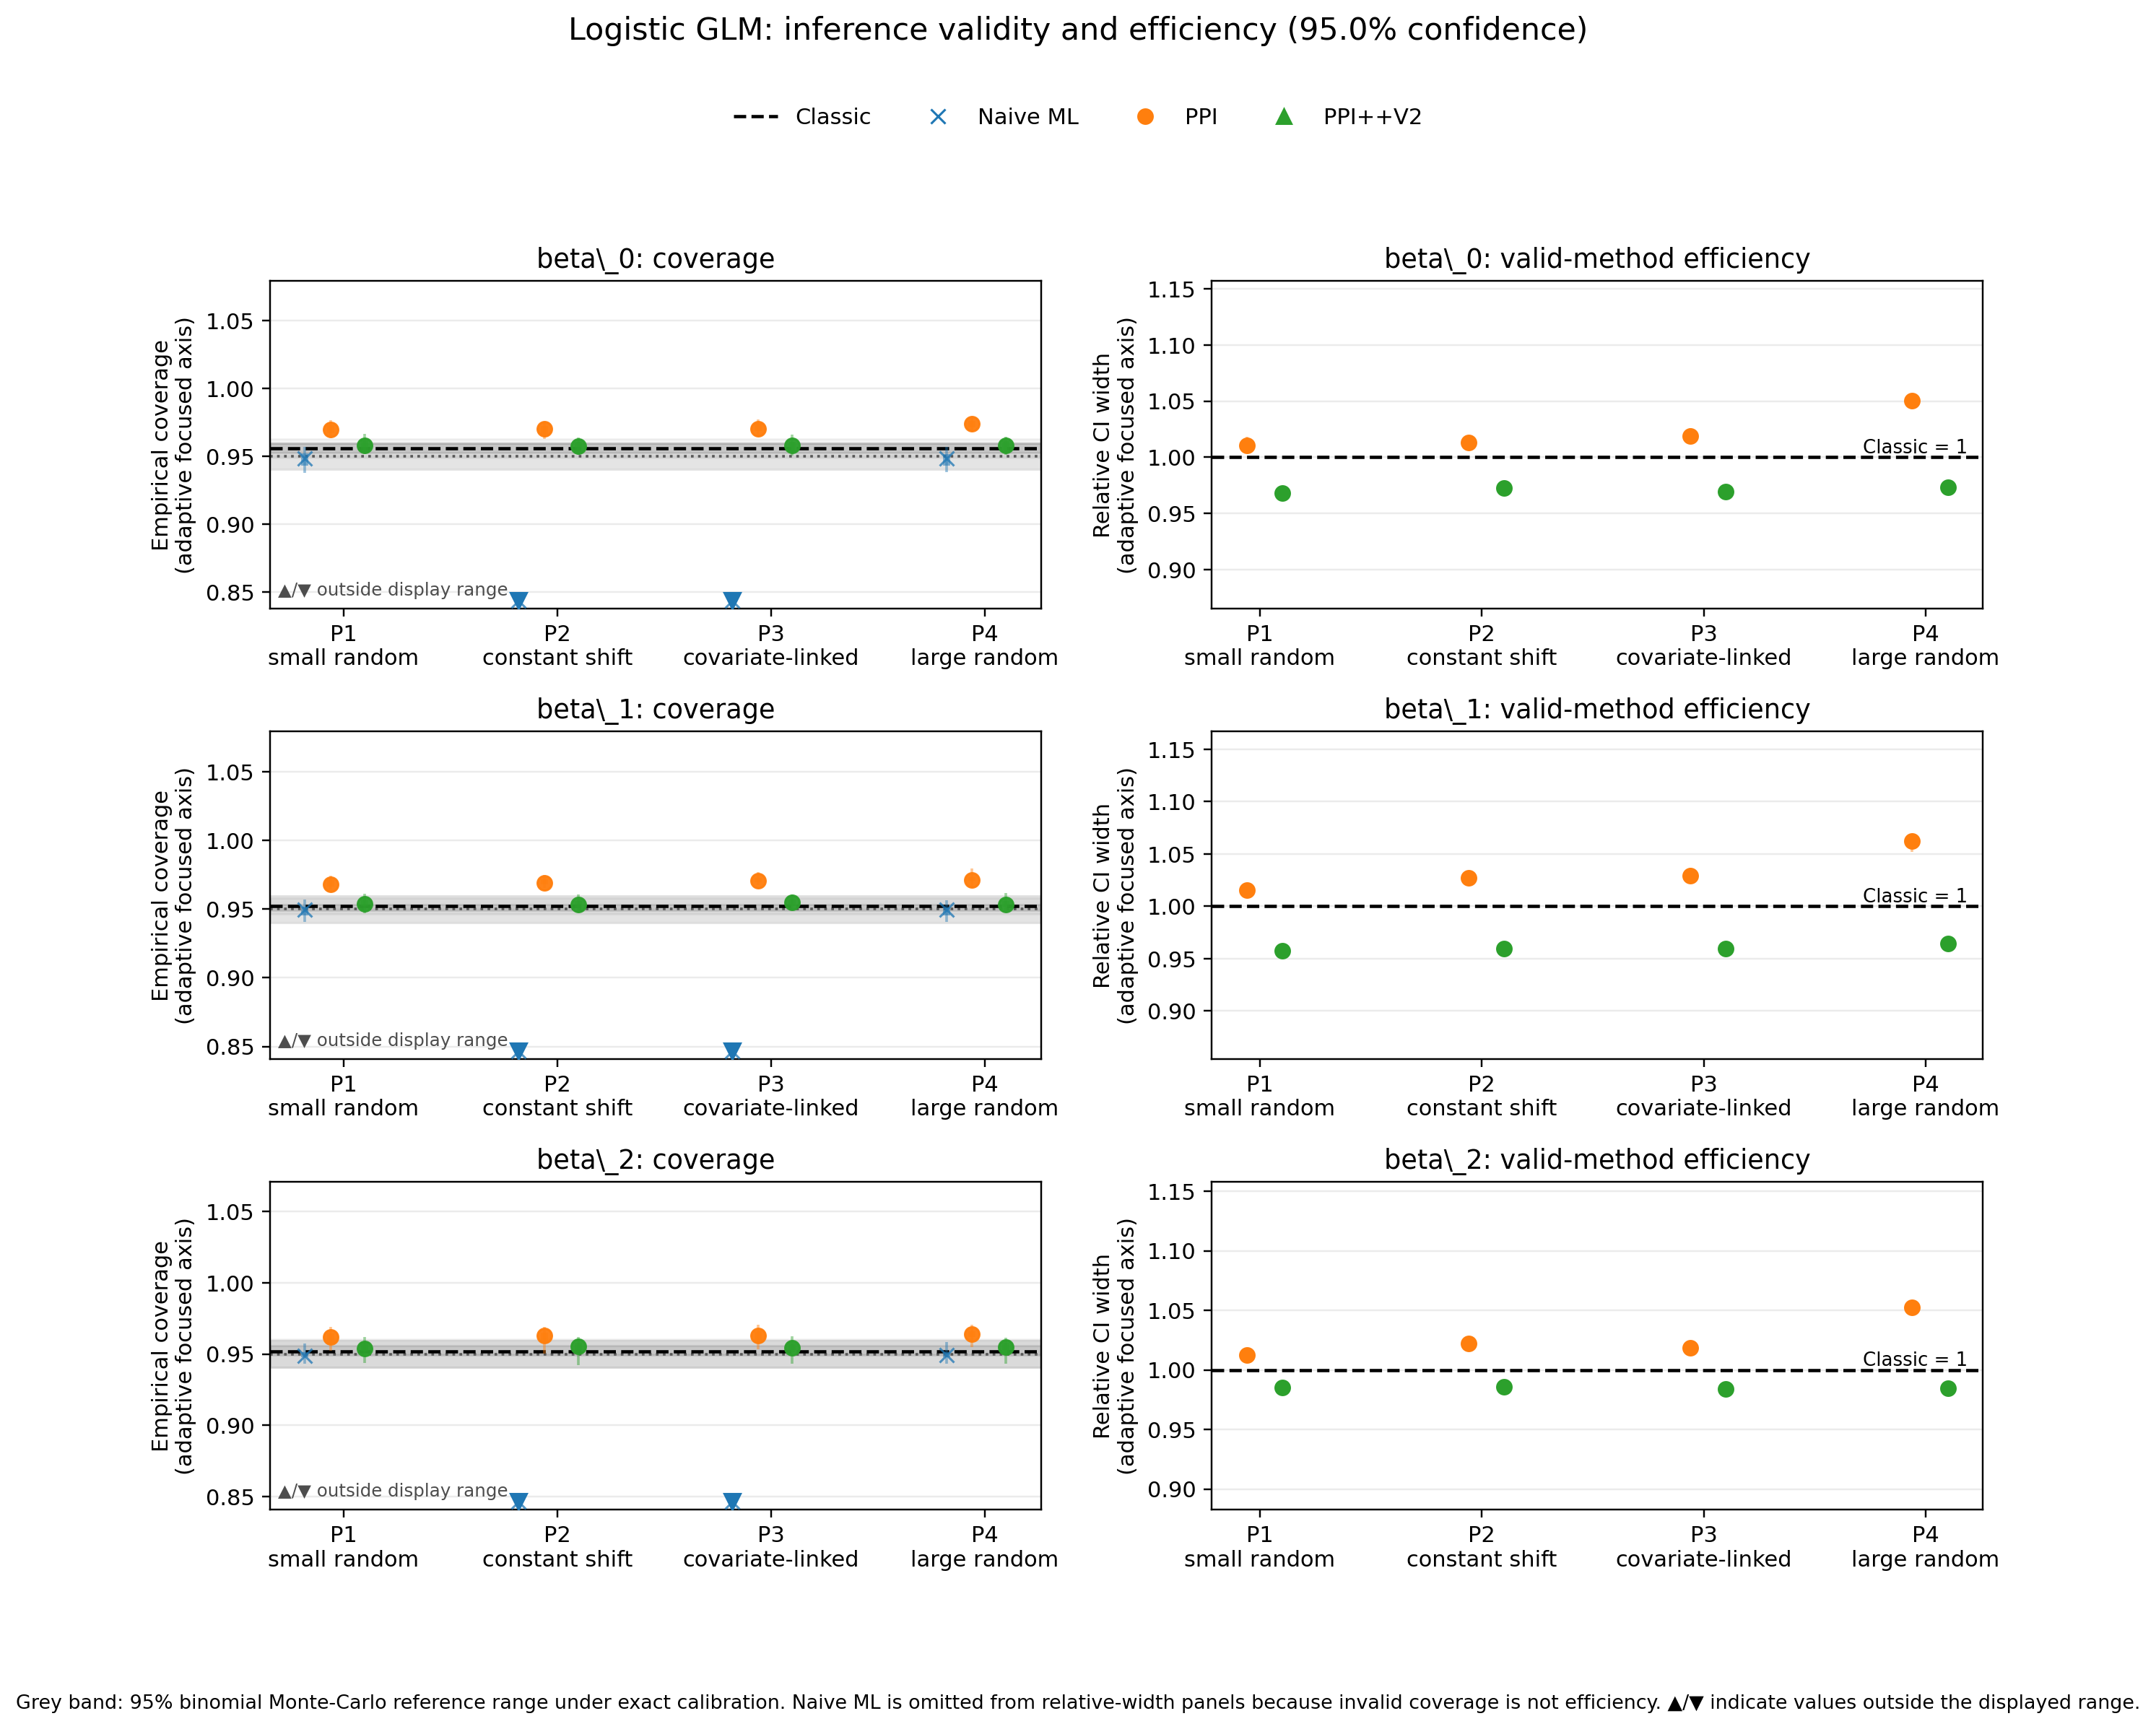

#### lr_main_cl_950.png

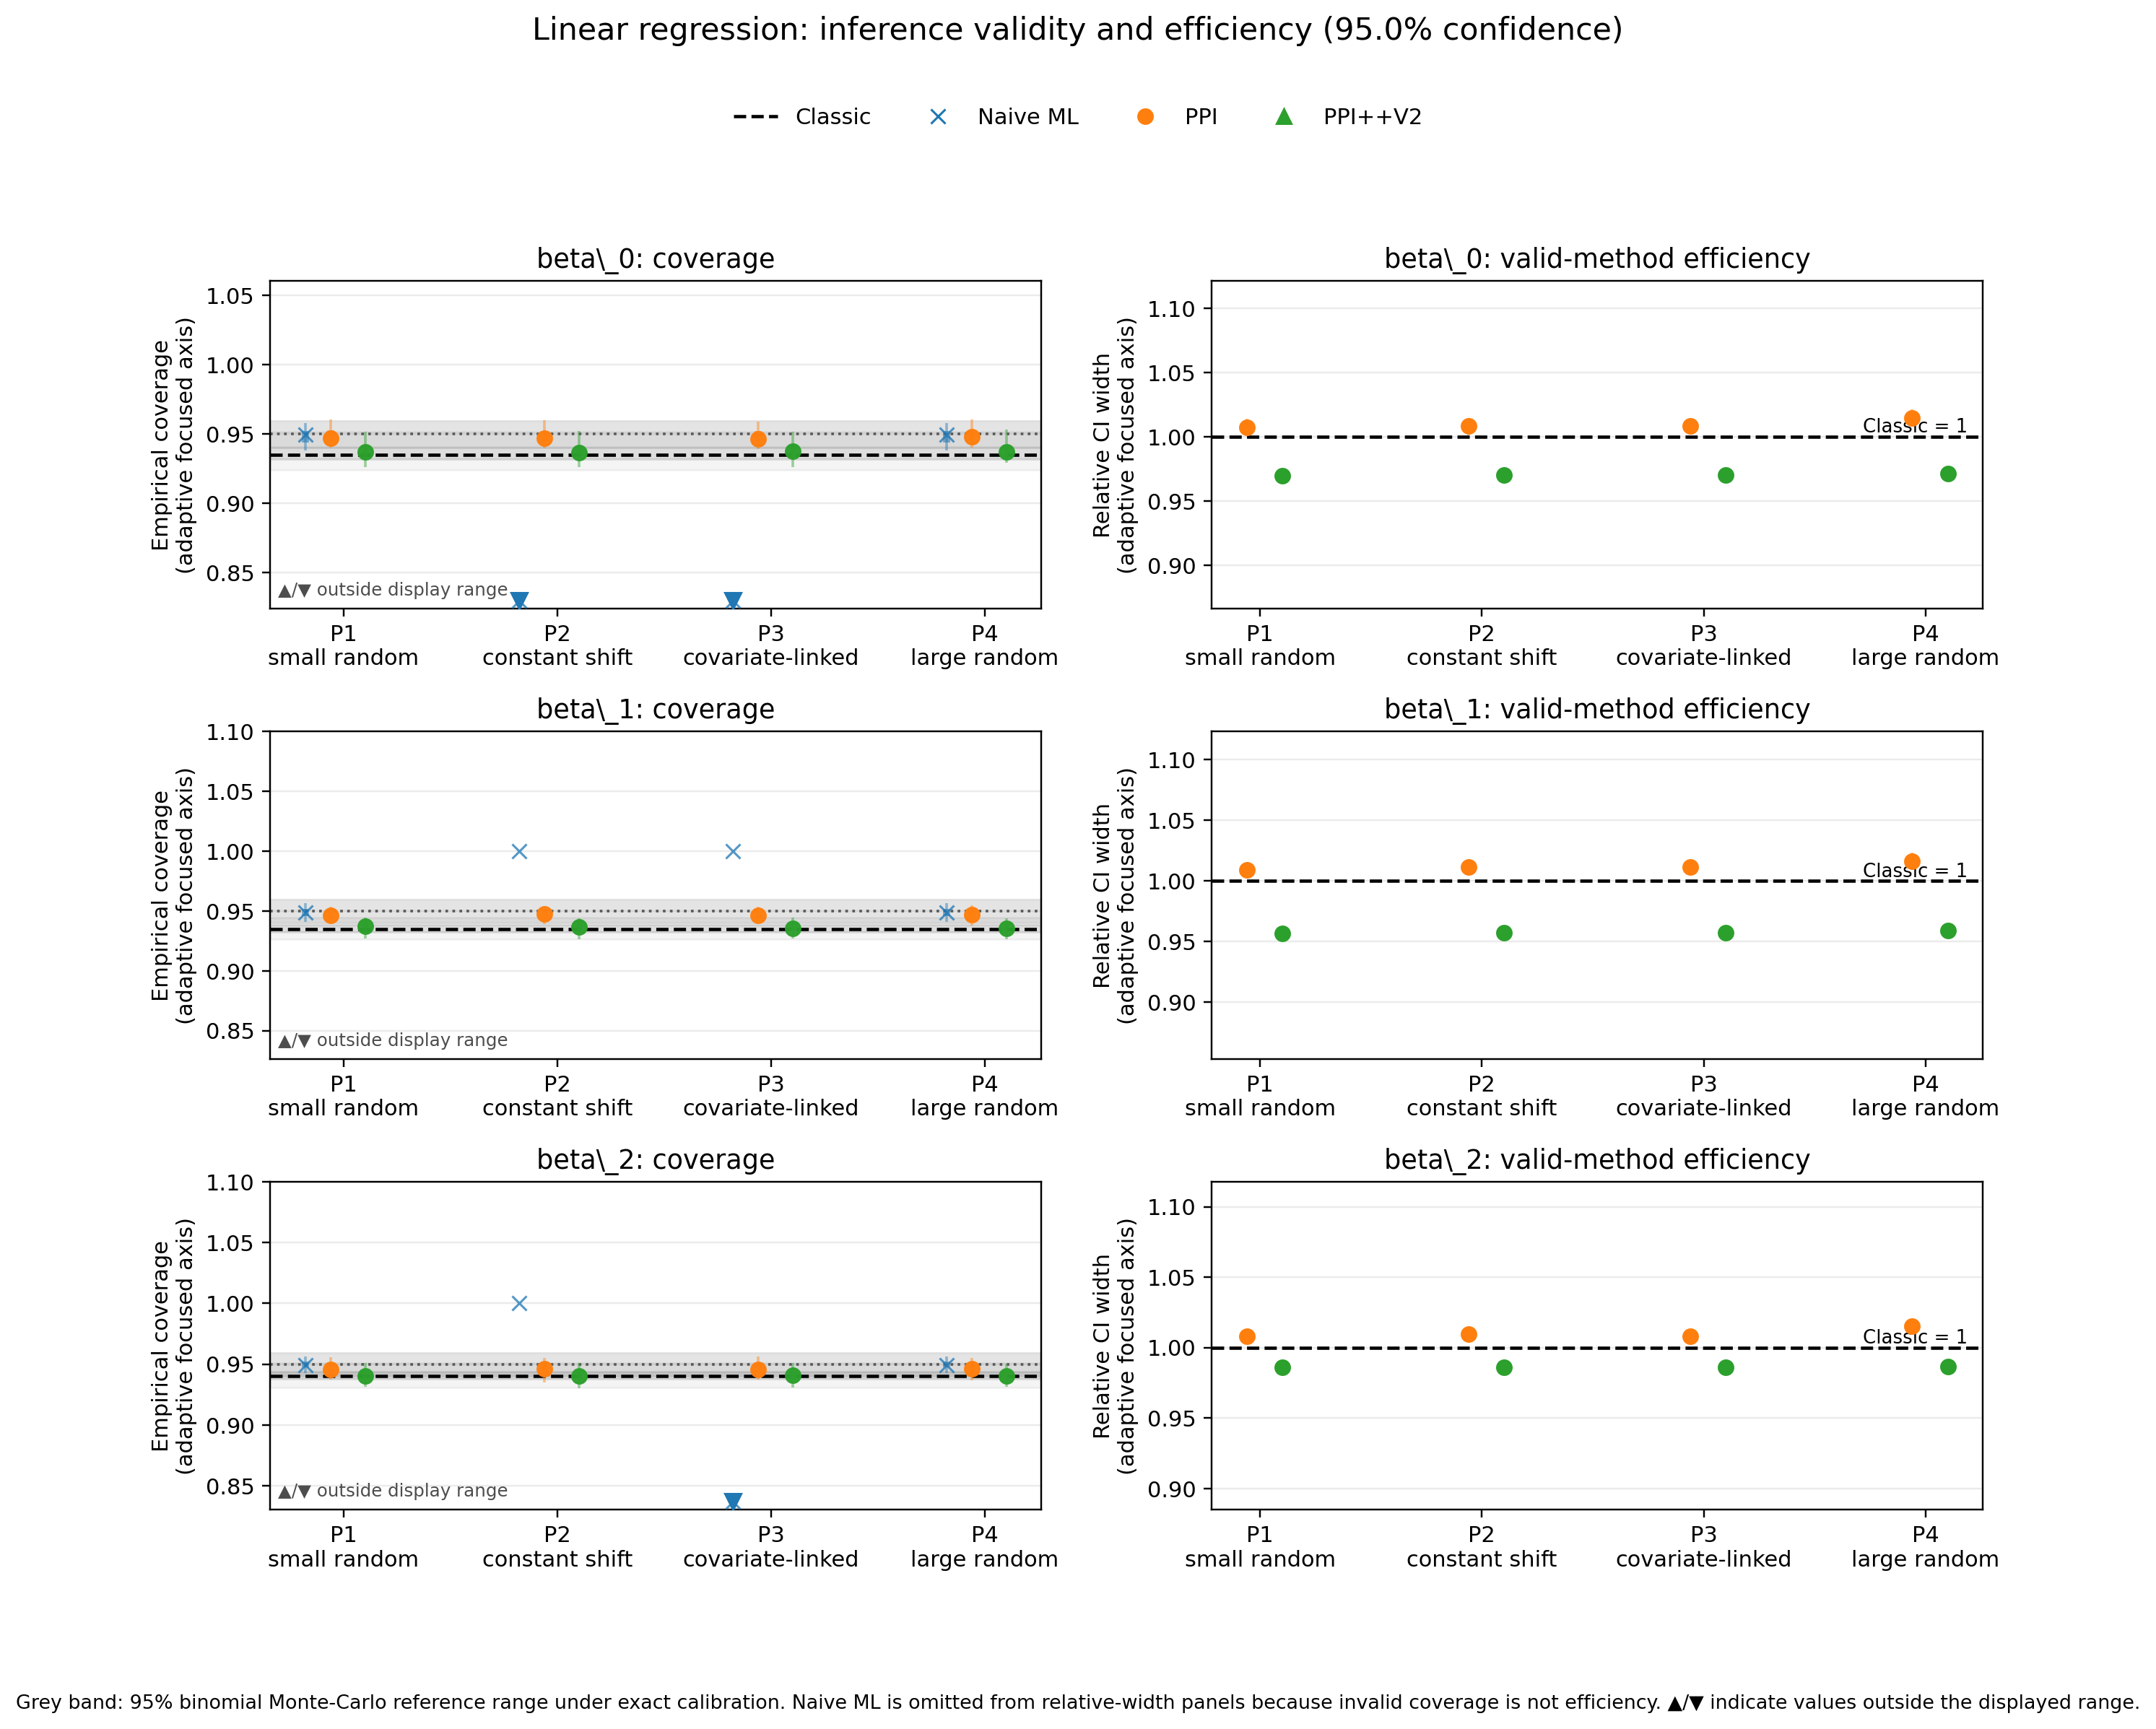

#### mean_main_cl_950.png

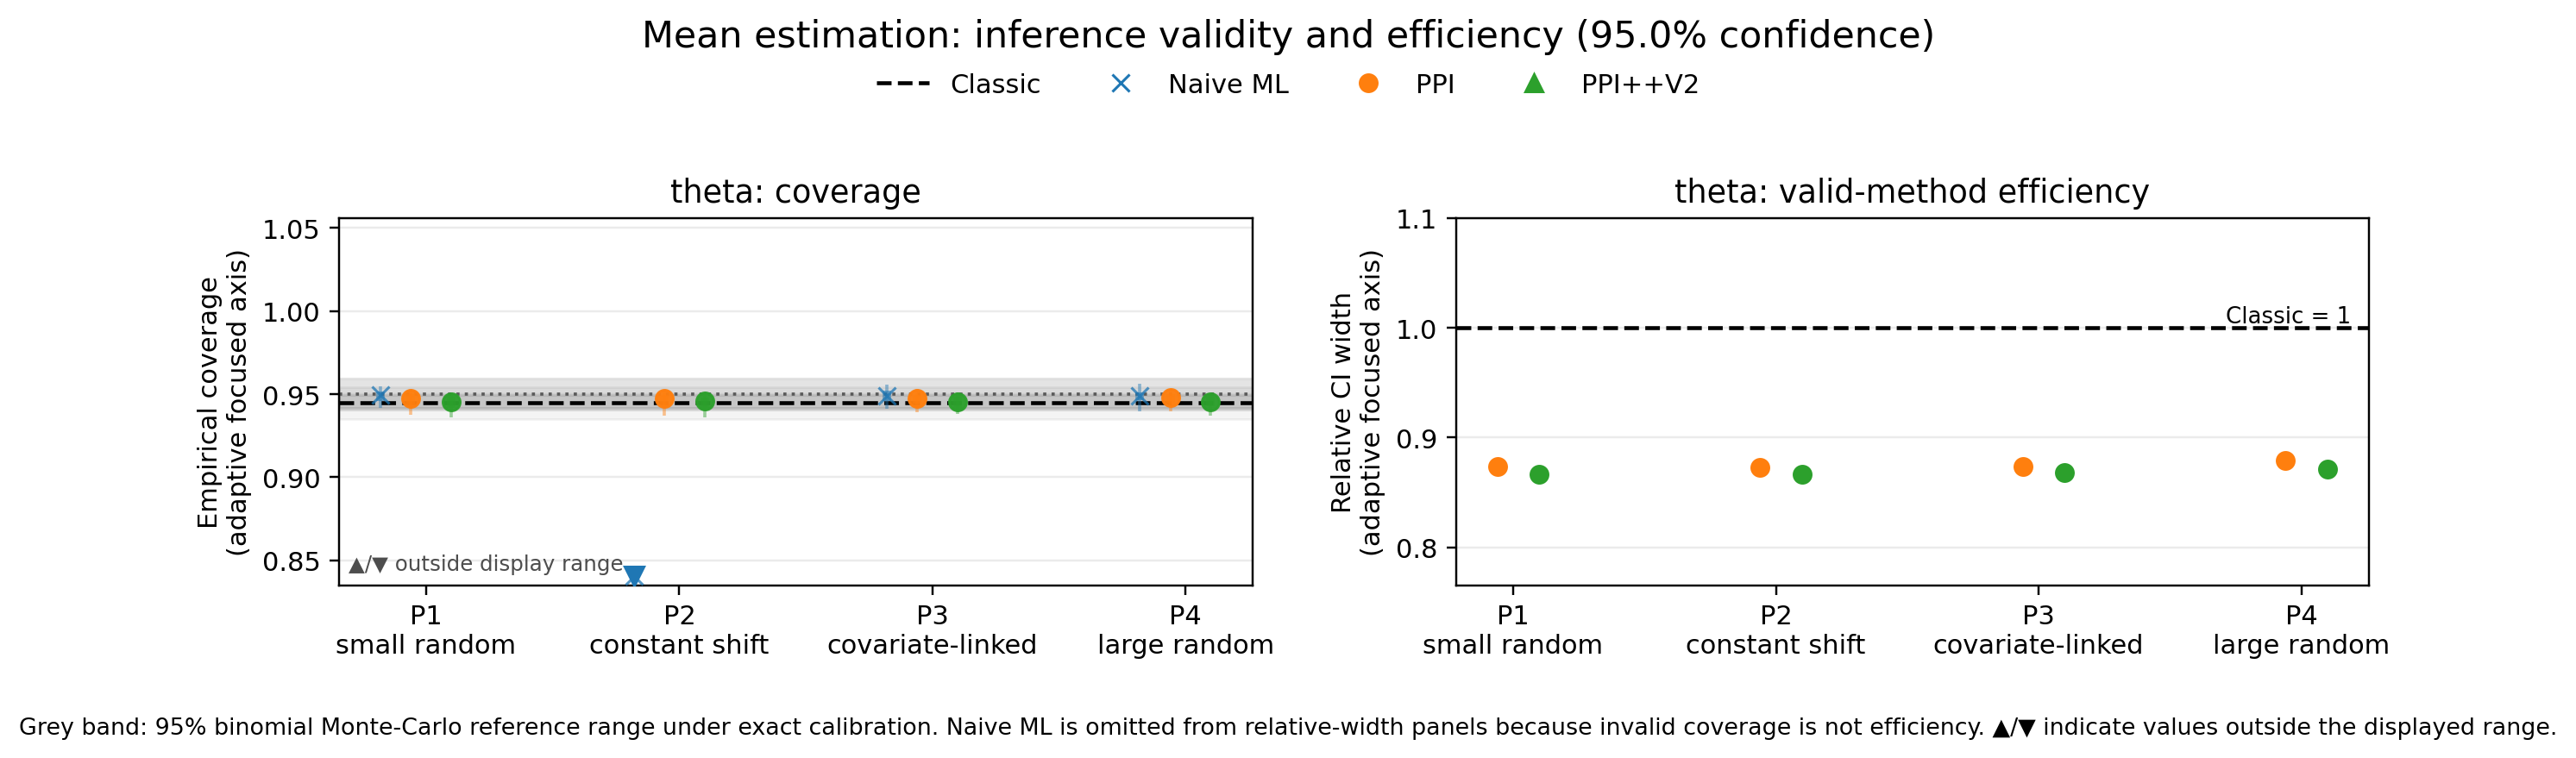

In [24]:
fig_dir = OUT / "figure"

if fig_dir.exists():
    figures = sorted([
        p for p in fig_dir.iterdir()
        if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".svg"]
    ])
    main_figs = [p for p in figures if "main_cl_950" in p.name]

    if not main_figs:
        display(Markdown("No main 95% figures found."))

    for p in main_figs:
        display(Markdown(f"#### {p.name}"))
        if p.suffix.lower() == ".svg":
            display(Markdown(f"[Open figure]({p.as_posix()})"))
        else:
            display(Image(filename=str(p)))
else:
    display(Markdown("No figure directory found."))


### 5.2 Calibration Figures


#### logistic_glm_calibration.png

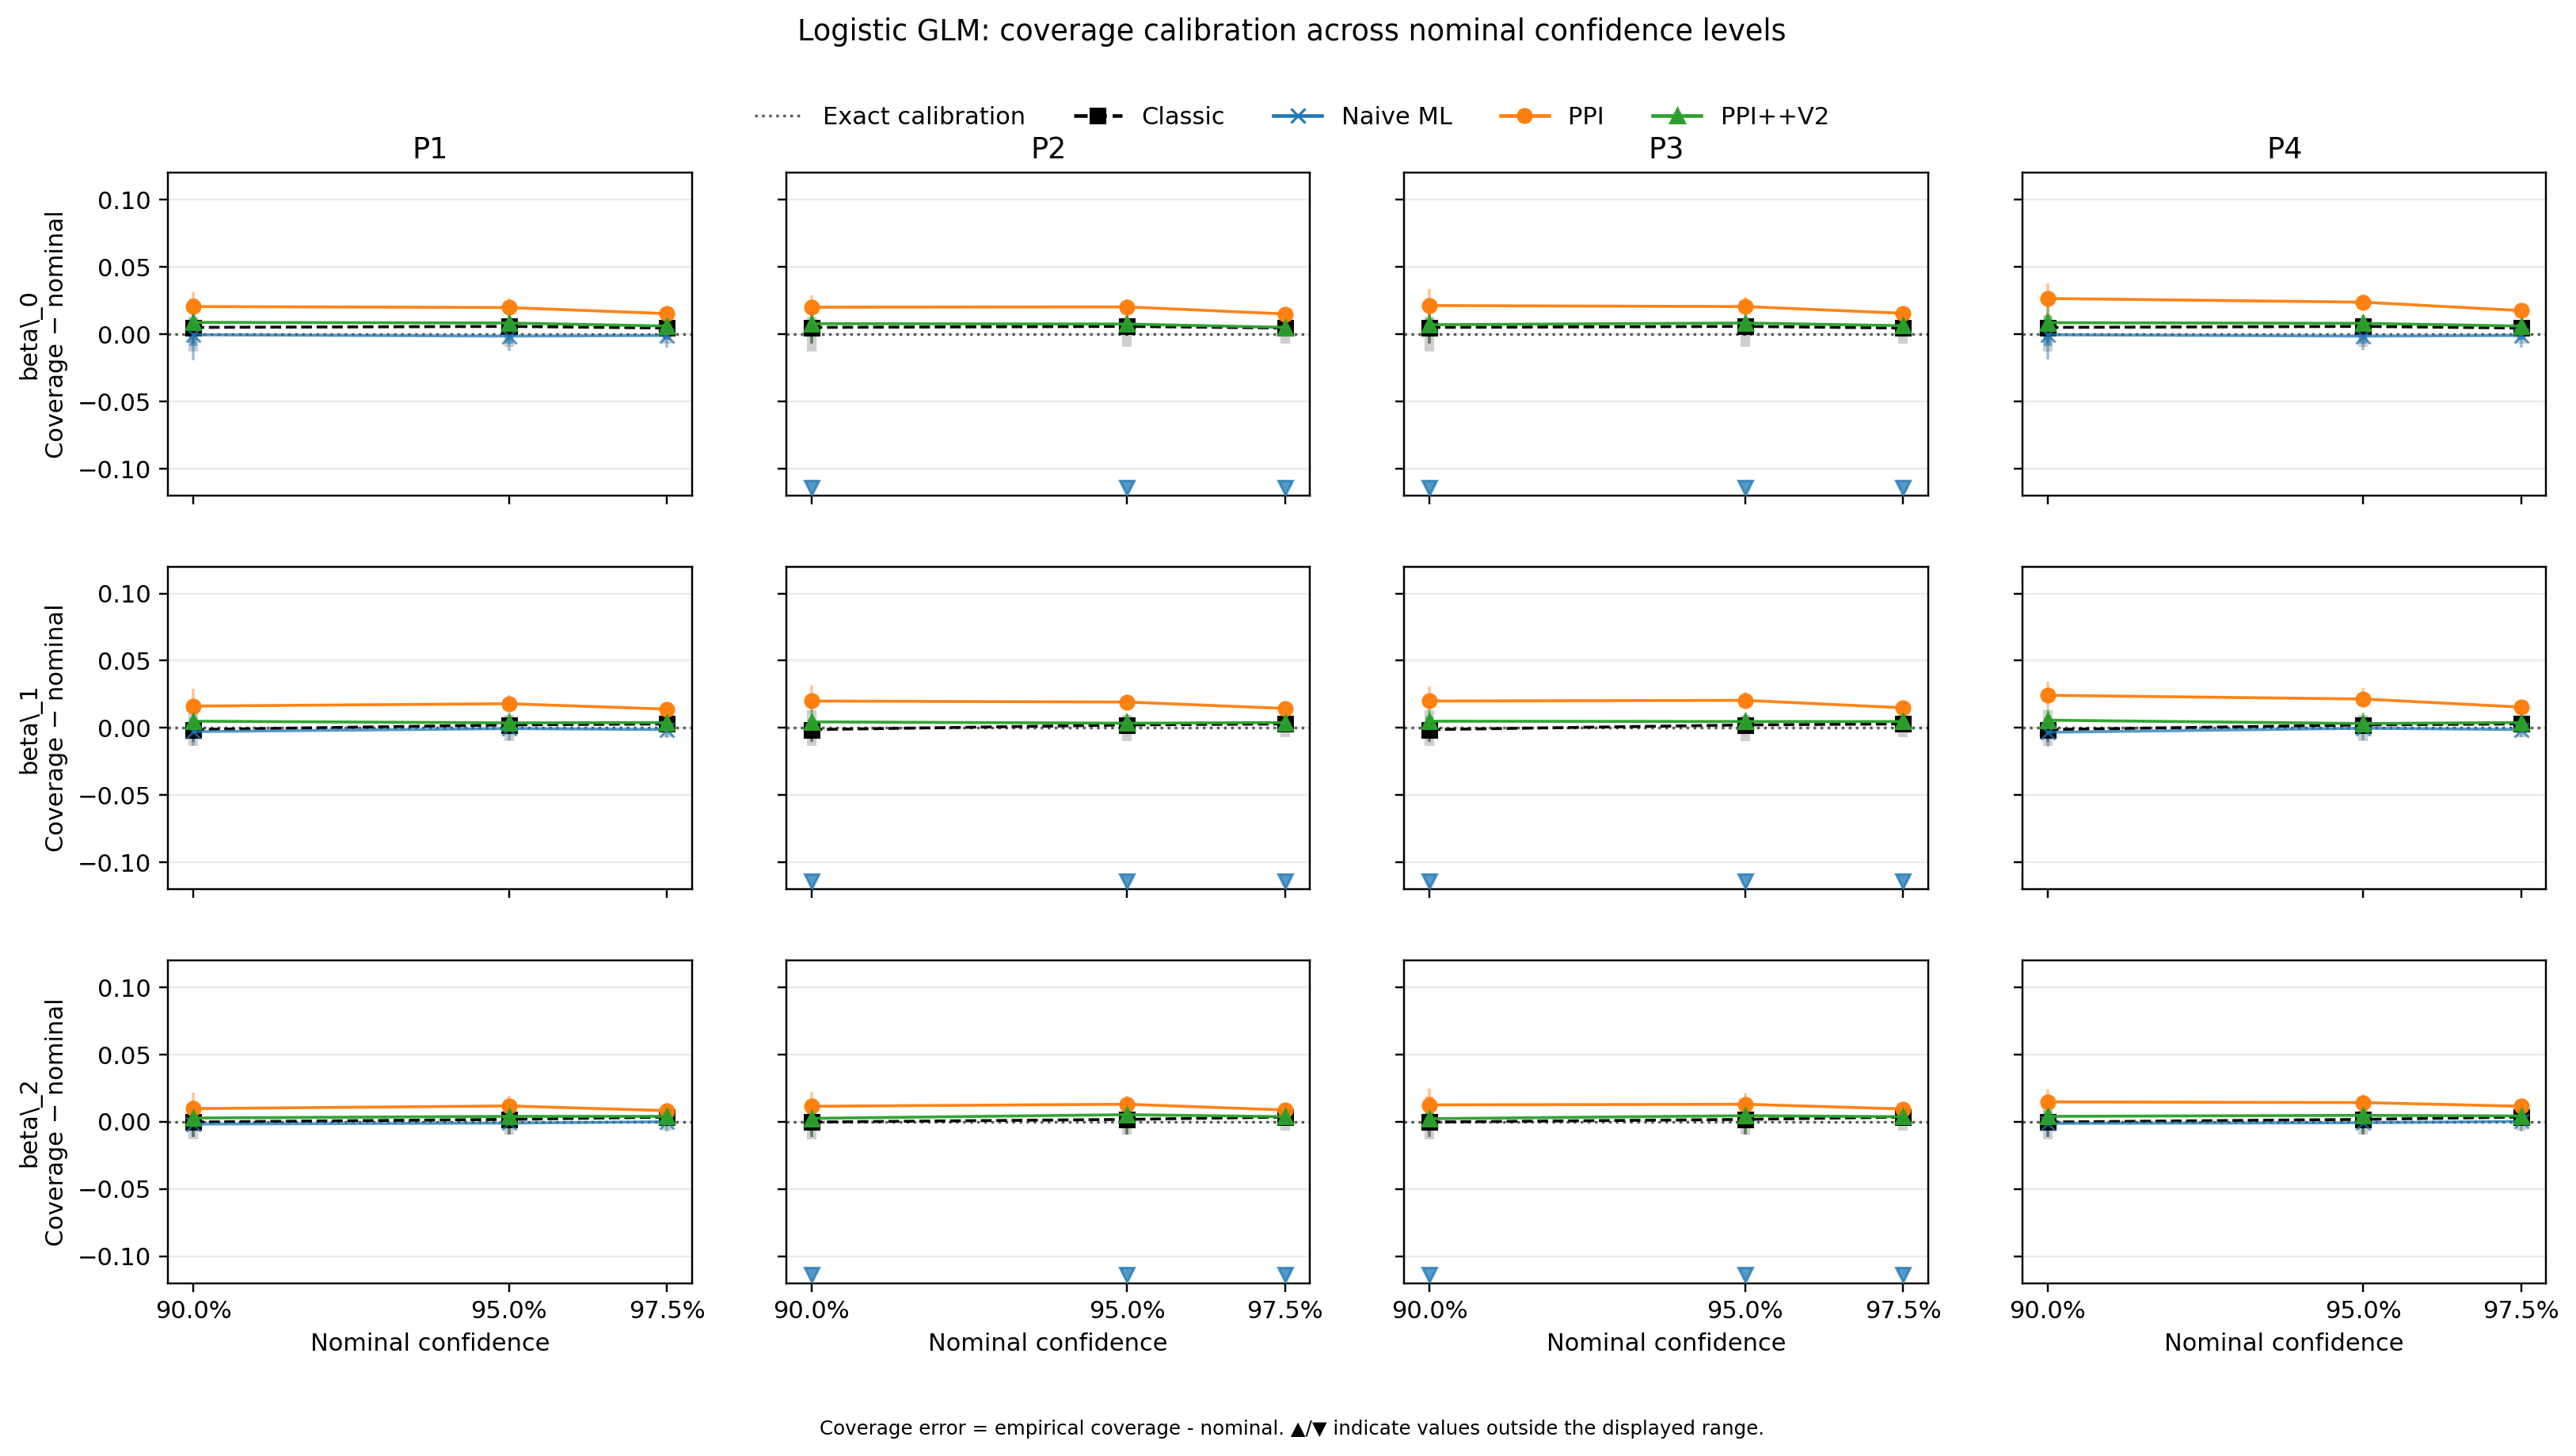

#### lr_calibration.png

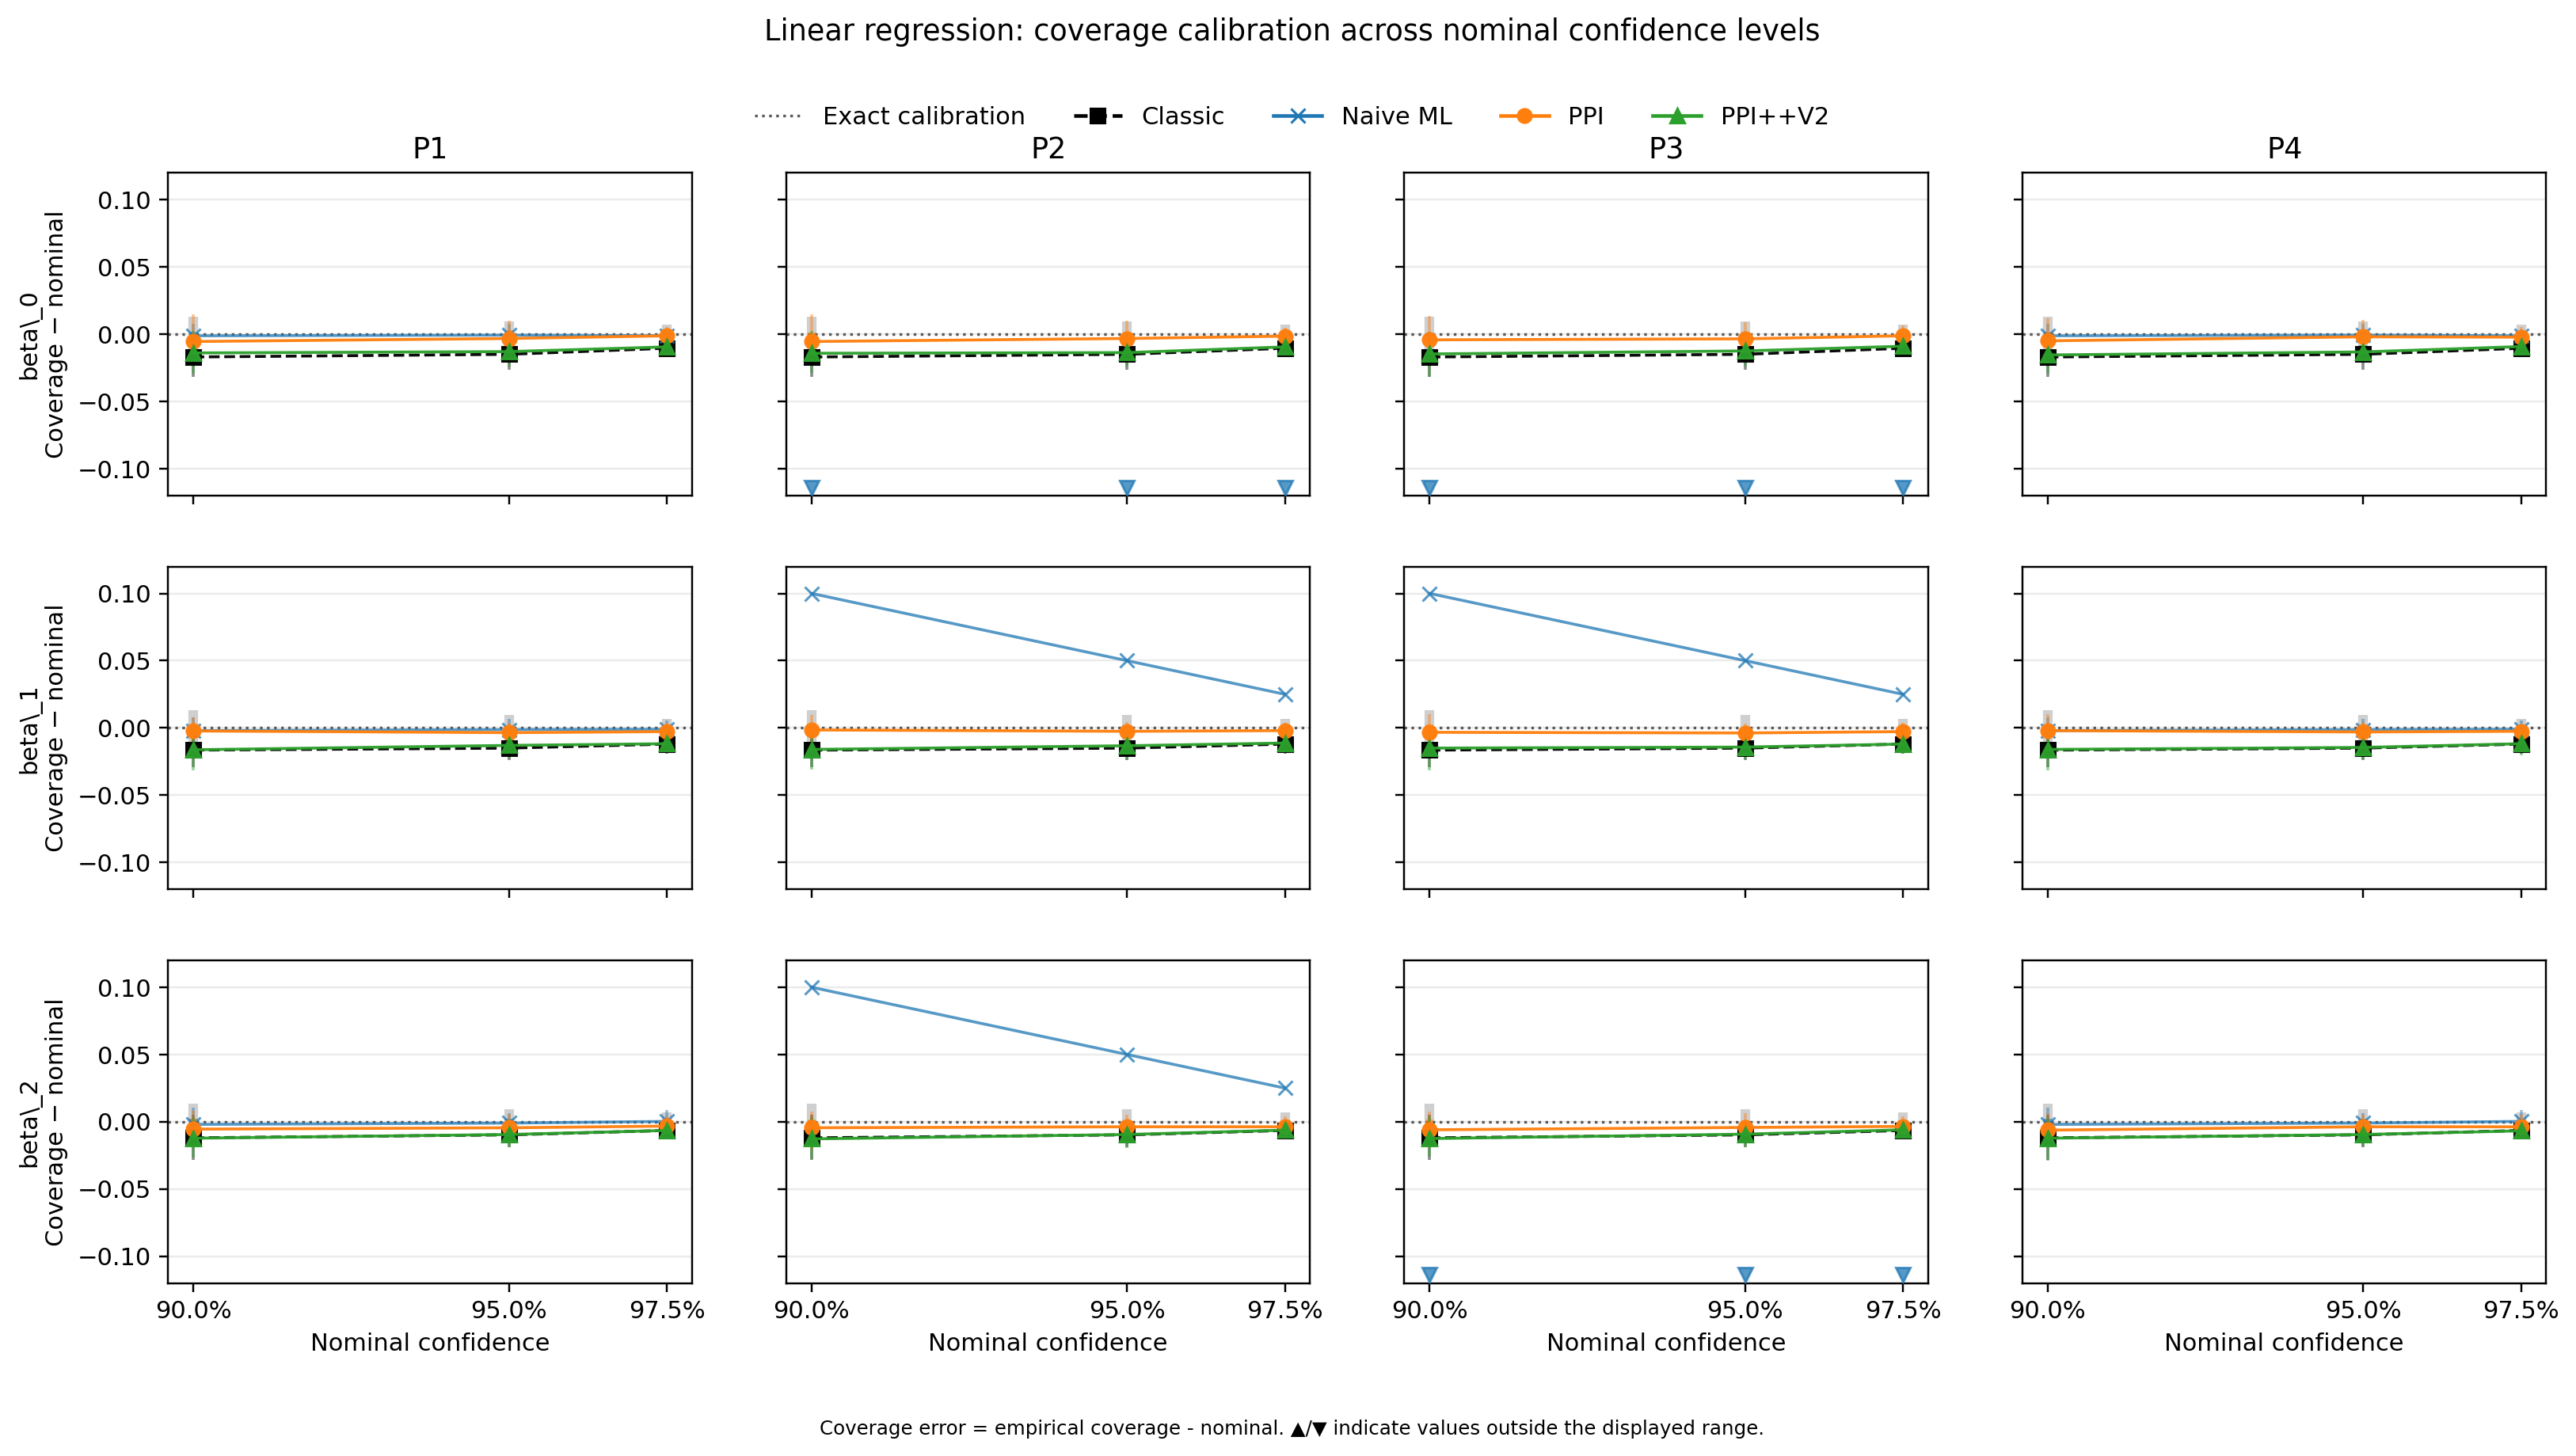

#### mean_calibration.png

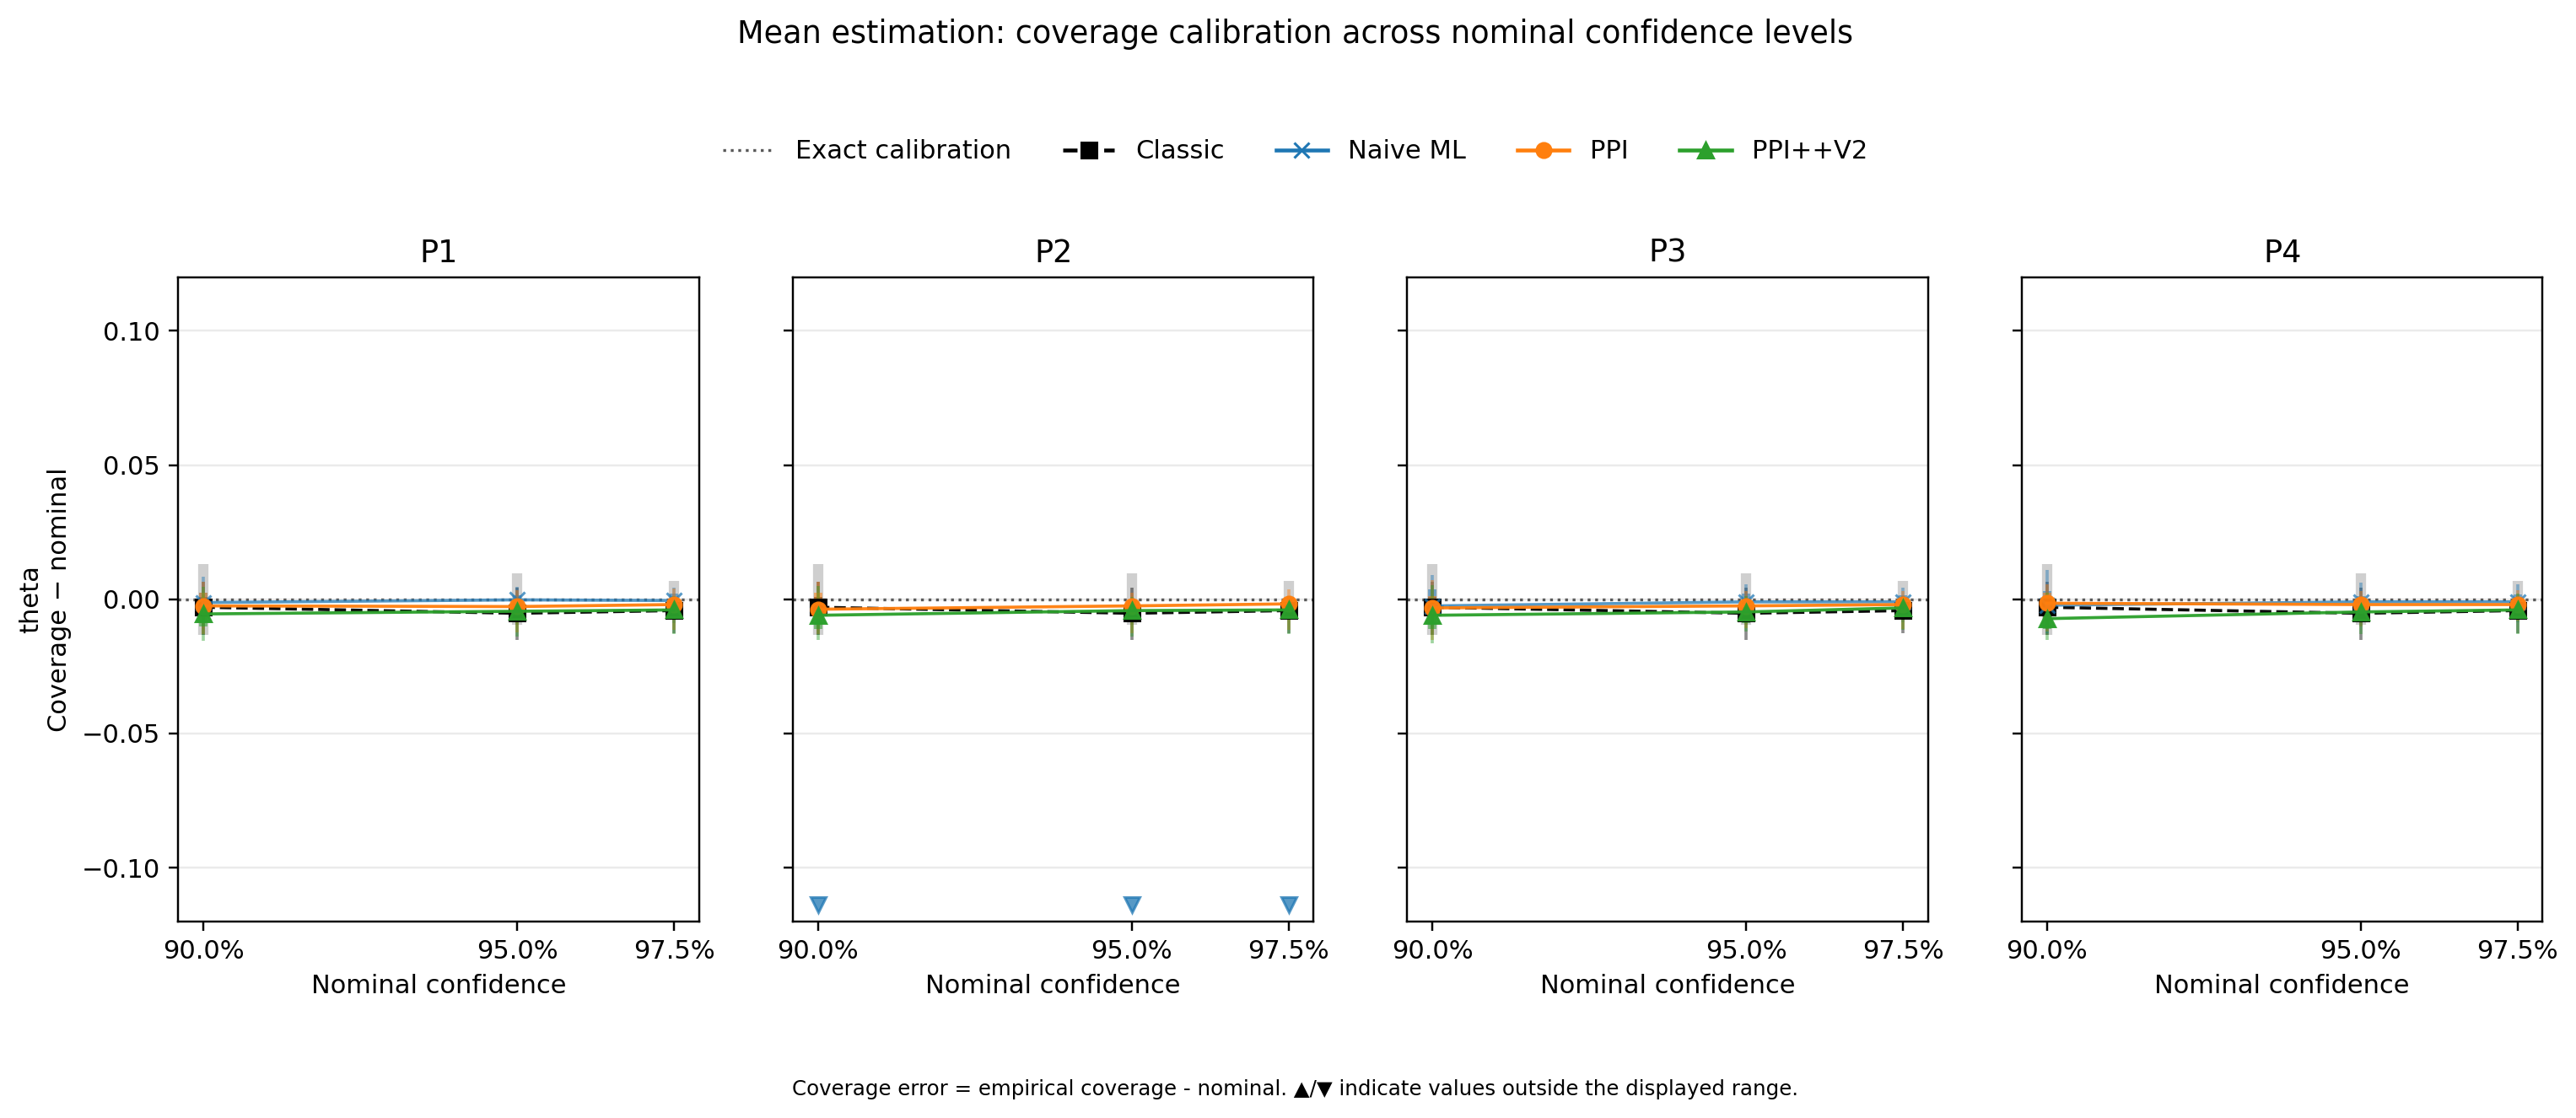

In [25]:
fig_dir = OUT / "figure"

if fig_dir.exists():
    figures = sorted([
        p for p in fig_dir.iterdir()
        if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".svg"]
    ])
    cal_figs = [p for p in figures if "calibration" in p.name]

    if not cal_figs:
        display(Markdown("No calibration figures found."))

    for p in cal_figs:
        display(Markdown(f"#### {p.name}"))
        if p.suffix.lower() == ".svg":
            display(Markdown(f"[Open figure]({p.as_posix()})"))
        else:
            display(Image(filename=str(p)))
else:
    display(Markdown("No figure directory found."))


### 5.3 Result Tables

The tables below keep only the columns needed to read the main 95% result.  
They are not intended to reproduce every raw output file.

For each row, read coverage first and width second.  
A smaller interval is useful only when empirical coverage remains close to the nominal level.


In [20]:
table_dir = OUT / "table"


def _first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def _round_numeric(df, digits=4):
    out = df.copy()
    num_cols = out.select_dtypes(include="number").columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def _filter_95(df):
    out = df.copy()

    cl_candidates = [
        "confidence_level",
        "conf_level",
        "level",
        "cl",
    ]

    cl_col = next((c for c in cl_candidates if c in out.columns), None)

    if cl_col is None:
        return out

    s = out[cl_col]

    # Compatible with 0.95, 95, 950, "0.95", "95", "950", "cl_950".
    s_str = s.astype(str).str.lower()

    mask = (
        s_str.isin(["0.95", "95", "950", "cl_950", "95%", "0.950"])
        | s_str.str.contains("950", regex=False)
    )

    # Numeric fallback.
    s_num = pd.to_numeric(s, errors="coerce")
    mask = mask | s_num.isin([0.95, 95, 950])

    if mask.any():
        return out.loc[mask].copy()

    return out


def _select_existing_columns(df, candidates):
    return [c for c in candidates if c in df.columns]


def _apply_display_labels(df):
    out = df.copy()
    if "method" in out.columns:
        out["method"] = out["method"].map(METHOD_LABELS).fillna(out["method"])
    if "scenario" in out.columns:
        out["scenario"] = out["scenario"].map(SCENARIO_LABELS).fillna(out["scenario"])
    return out


display(Markdown("#### Main 95% numerical summary"))

main_table_priority = [
    table_dir / "plot_summary.csv",
    table_dir / "seed0_metrics.csv",
    table_dir / "metrics_seed0.csv",
]

main_path = _first_existing(main_table_priority)

main_cols = [
    "scenario",
    "profile",
    "target",
    "parameter",
    "method",
    "coverage",
    "empirical_coverage",
    "coverage_error",
    "center_coverage_error",
    "avg_width",
    "average_width",
    "average_ci_width",
    "ci_width",
    "relative_width",
    "rel_width",
    "center_relative_ci_width",
]

if main_path is None:
    display(Markdown("No main result table found."))
else:
    try:
        main_df = pd.read_csv(main_path)
        main_df = _filter_95(main_df)

        cols = _select_existing_columns(main_df, main_cols)
        if cols:
            main_show = main_df[cols].copy()
        else:
            main_show = main_df.copy()

        main_show = _apply_display_labels(main_show)
        main_show = _round_numeric(main_show)

        display(Markdown(
            f"Source table: `{main_path.name}`. "
            "The table is filtered to the 95% confidence level when the confidence-level column is available."
        ))
        display(main_show.head(60))

    except Exception as e:
        display(Markdown(f"Could not read `{main_path.name}`: `{e}`"))


#### Main 95% numerical summary

Source table: `plot_summary.csv`. The table is filtered to the 95% confidence level when the confidence-level column is available.

,scenario,profile,target,method,center_coverage_error,center_relative_ci_width
1,Logistic GLM,P1,beta_0,Naive ML,-0.0015,0.0072
4,Logistic GLM,P1,beta_0,PPI,0.0198,1.0108
7,Logistic GLM,P1,beta_0,PPI++V2,0.0082,0.9683
10,Logistic GLM,P2,beta_0,Naive ML,-0.9500,0.0037
13,Logistic GLM,P2,beta_0,PPI,0.0202,1.0132
16,Logistic GLM,P2,beta_0,PPI++V2,0.0075,0.9727
19,Logistic GLM,P3,beta_0,Naive ML,-0.9500,0.0021
22,Logistic GLM,P3,beta_0,PPI,0.0205,1.0187
25,Logistic GLM,P3,beta_0,PPI++V2,0.0082,0.9695
28,Logistic GLM,P4,beta_0,Naive ML,-0.0015,0.0719


## 6. Raw Output Files

The files below are kept for audit and reproducibility.  
They are not expanded in the notebook because the main result display above already extracts the columns needed for interpretation.


In [22]:
display(Markdown("### Available raw output files"))

raw_specs = [
    ("table/seed0_metrics.csv", "Seed-0 aggregate metrics for full-mode output."),
    ("table/metrics_seed0.csv", "Seed-0 aggregate metrics for fast-mode output."),
    ("table/all_seed_metrics.csv", "Complete seed-level metrics."),
    ("table/robustness_summary.csv", "Robustness summary across outer seeds."),
    ("table/plot_summary.csv", "Exact aggregate quantities used for plotting."),
    ("other/diagnostics_seed0.parquet", "Convergence, Hessian condition number, and PPI++V2 lambda diagnostics."),
    ("other/diagnostics_seed0.csv.gz", "Compressed fallback for diagnostics."),
    ("other/replicate_results_seed0.parquet", "Interval-level replicate audit records."),
    ("other/replicate_results_seed0.csv.gz", "Compressed fallback for replicate-level audit records."),
]

rows = []
for rel, purpose in raw_specs:
    p = OUT / rel
    rows.append({
        "File": rel,
        "Exists": p.exists(),
        "Purpose": purpose,
    })

raw_df = pd.DataFrame(rows)
display(raw_df)


### Available raw output files

,File,Exists,Purpose
0,table/seed0_metrics.csv,True,Seed-0 aggregate metrics for full-mode output.
1,table/metrics_seed0.csv,False,Seed-0 aggregate metrics for fast-mode output.
2,table/all_seed_metrics.csv,True,Complete seed-level metrics.
3,table/robustness_summary.csv,True,Robustness summary across outer seeds.
4,table/plot_summary.csv,True,Exact aggregate quantities used for plotting.
5,other/diagnostics_seed0.parquet,True,"Convergence, Hessian condition number, and PPI..."
6,other/diagnostics_seed0.csv.gz,False,Compressed fallback for diagnostics.
7,other/replicate_results_seed0.parquet,True,Interval-level replicate audit records.
8,other/replicate_results_seed0.csv.gz,False,Compressed fallback for replicate-level audit ...
